<a href="https://colab.research.google.com/github/vikashkumar97983282-glitch/Deep_Learning/blob/main/Vansishing_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential
import matplotlib.pyplot as plt

In [ ]:
X,y = make_moons(n_samples=250,noise=0.1,random_state=42)

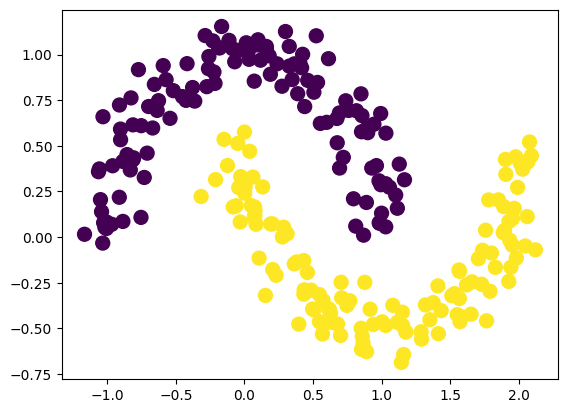

In [ ]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [ ]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
old_weights = model.get_weights()[0]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.4900 - loss: 0.7053
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.7004 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6974 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6956 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6938 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6931 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4900 - loss: 0.6921 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6916 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5850 - loss: 0.6912 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6750 - loss: 0.6907 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7200 - loss: 0.6905 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7750 - los

In [ ]:
new_weights = model.get_weights()[0]

In [ ]:
new_weights

array([[ 0.774256  ,  1.0871319 , -0.45910338, -0.15154067,  1.0174236 ,
        -0.5265146 ,  0.5646787 , -0.42987454,  0.13647057, -0.87316734],
       [-1.0409074 , -1.6807266 ,  1.3364131 ,  0.8282033 , -0.9089472 ,
         1.6413474 , -1.1822841 ,  1.5866545 , -1.6131977 ,  1.2122337 ]],
      dtype=float32)

In [ ]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [ ]:
gradient = (old_weights-new_weights)/0.001
percent_change = abs(100*(old_weights-new_weights)/old_weights)

In [ ]:
gradient

array([[ -751.2281 ,  -515.74756,   755.71295,   642.1406 ,  -690.4373 ,
          775.6918 ,  -799.05695,   768.52124,  -826.6477 ,   739.18854],
       [ 1092.9829 ,   981.1033 ,  -990.6246 ,  -812.4153 ,  1100.4056 ,
        -1046.6396 ,  1076.1272 , -1010.8771 ,   997.75336, -1134.4116 ]],
      dtype=float32)

In [ ]:
new_weights

array([[ 0.774256  ,  1.0871319 , -0.45910338, -0.15154067,  1.0174236 ,
        -0.5265146 ,  0.5646787 , -0.42987454,  0.13647057, -0.87316734],
       [-1.0409074 , -1.6807266 ,  1.3364131 ,  0.8282033 , -0.9089472 ,
         1.6413474 , -1.1822841 ,  1.5866545 , -1.6131977 ,  1.2122337 ]],
      dtype=float32)

In [ ]:
old_weights

array([[ 0.02302784,  0.57138425,  0.29660958,  0.49059993,  0.32698625,
         0.24917722, -0.23437828,  0.3386467 , -0.6901772 , -0.13397878],
       [ 0.05207562, -0.69962335,  0.34578854,  0.01578802,  0.19145846,
         0.59470767, -0.10615677,  0.57577735, -0.6154443 ,  0.07782197]],
      dtype=float32)